In [1]:
import numpy as np
import pandas as pd
from environment import custom_four_rooms
from helpers import get_inverted_model, get_seeded_inverted_models
from inverse_prediction import get_trajectories, get_step_distributions, build_environment_kernel, get_exact_step_distributions
from visualisations import show_distribution, show_distribution_comparison, plot_seeded_phase1_metrics
from analysis_functions import evaluate_seeded_models_exact

In [21]:
run_trajectories_single = True;
run_mathematical_multi = True;

# Prediction Tests

In [22]:
env = custom_four_rooms(isWindy=True)
goals = [
    (1, 1),
    (1, 9),
    (9, 1),
    (9, 9),
    (5, 3)]

In [23]:
if run_trajectories_single:
  Q, P_hat, bellman_residual = get_inverted_model(env, goals, n_episodes=100000)

## Trajectory based

In [24]:
if run_trajectories_single:
  goal_index = 3
  goal_state = goals[goal_index]
  n_steps = 50
  n_trajectories = 100000

  model_trajectories = get_trajectories(
      env,
      Q,
      goal_index=goal_index,
      goal_state=goal_state,
      n_trajectories=n_trajectories,
      n_steps=n_steps,
      source="model",
      P_hat=P_hat
  )

  environment_trajectories = get_trajectories(
      env,
      Q,
      goal_index=goal_index,
      goal_state=goal_state,
      n_trajectories=n_trajectories,
      n_steps=n_steps,
      source="environment"
  )

  model_distributions = get_step_distributions(model_trajectories)

  environment_distributions = get_step_distributions(environment_trajectories)


In [25]:
if run_trajectories_single:
  visualised_steps = range(0, 10)

In [26]:
if run_trajectories_single:
  live_trajectory = environment_trajectories[50]

### Internal model only

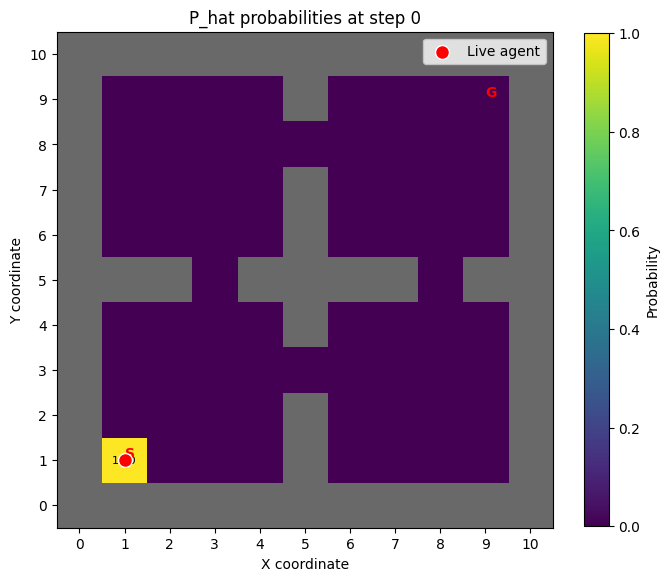

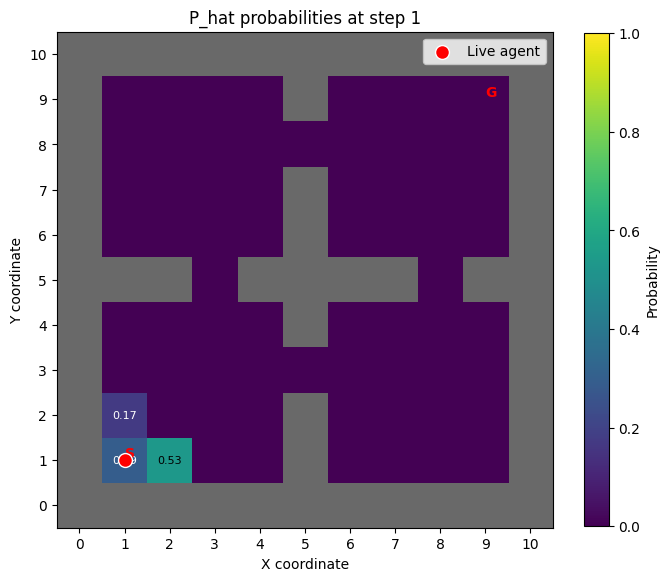

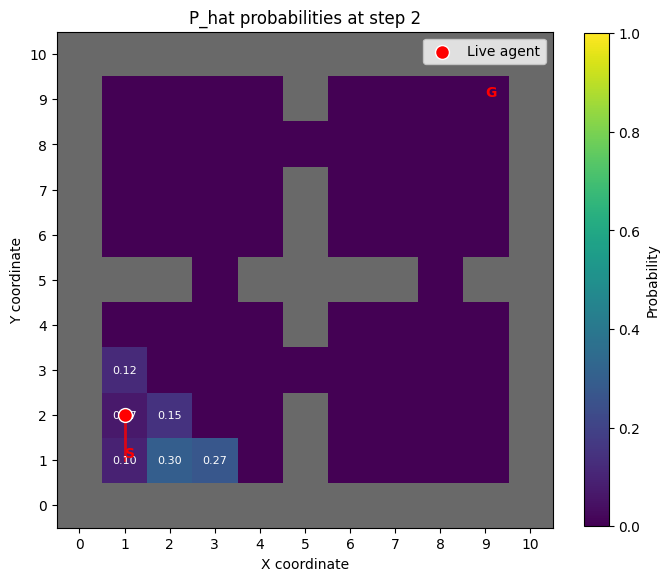

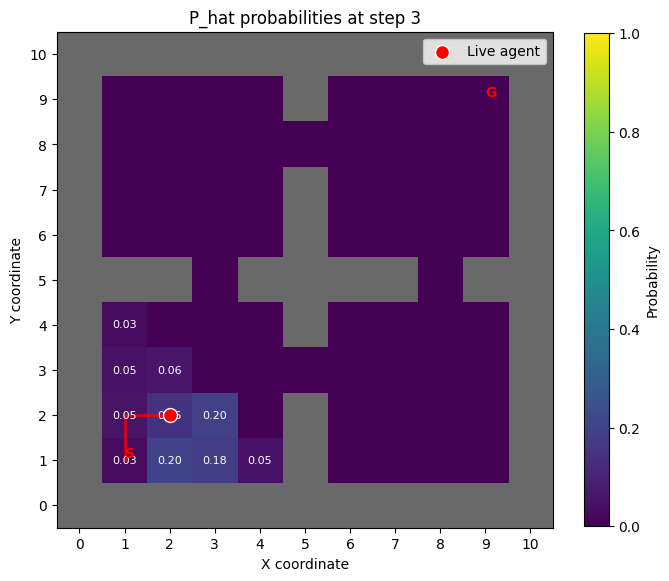

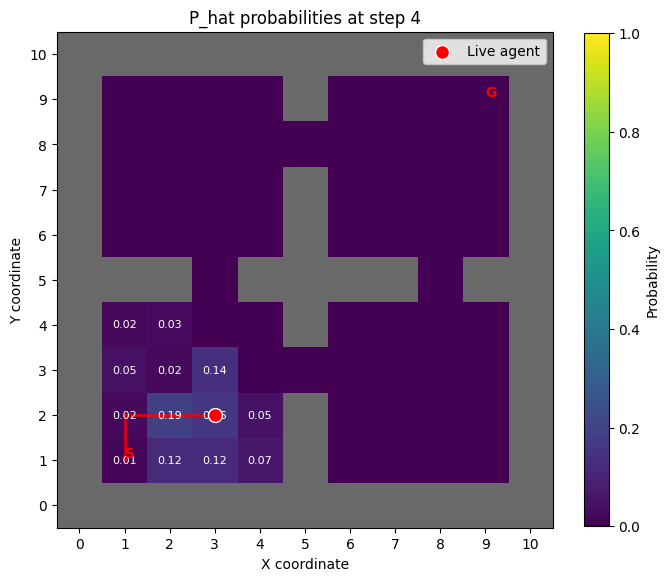

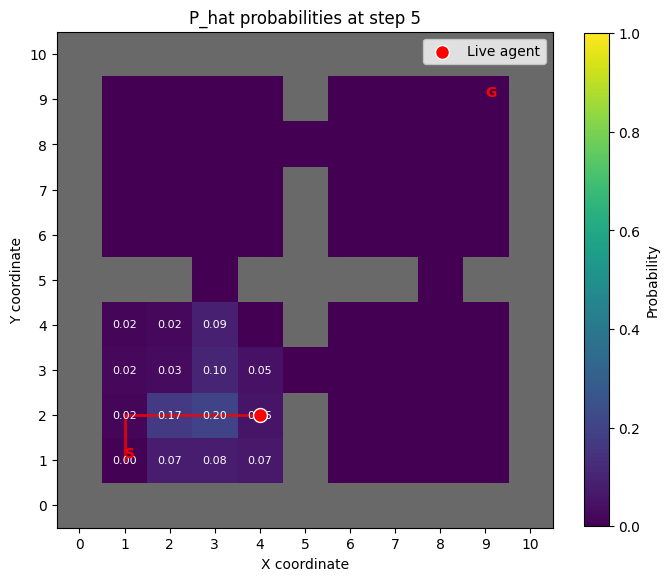

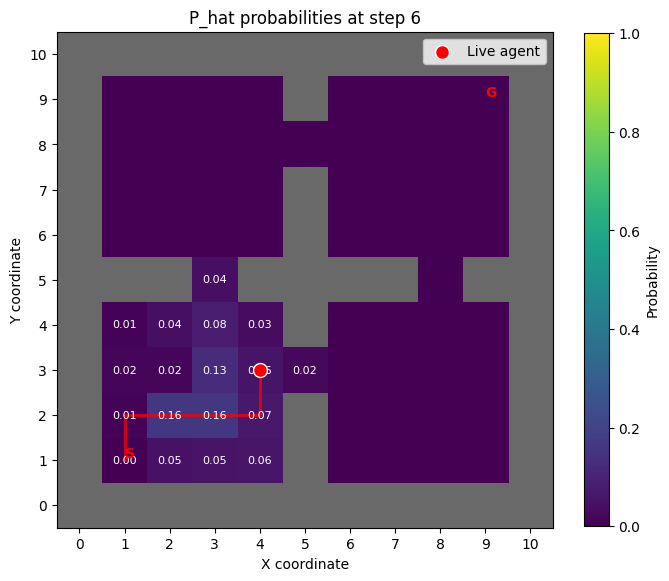

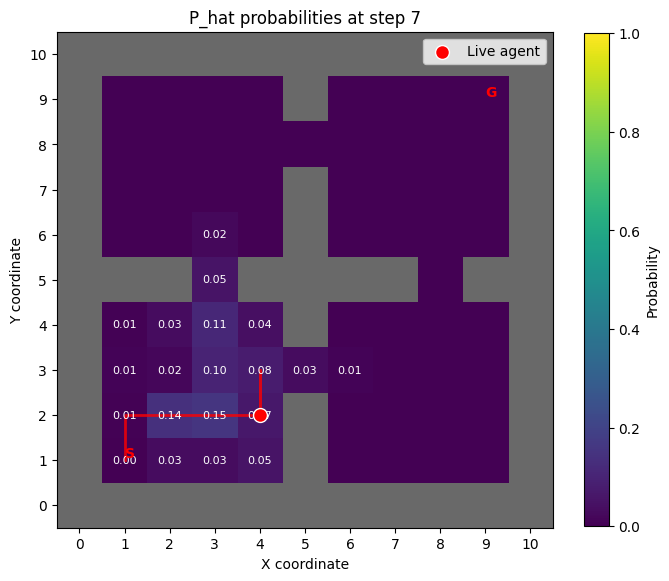

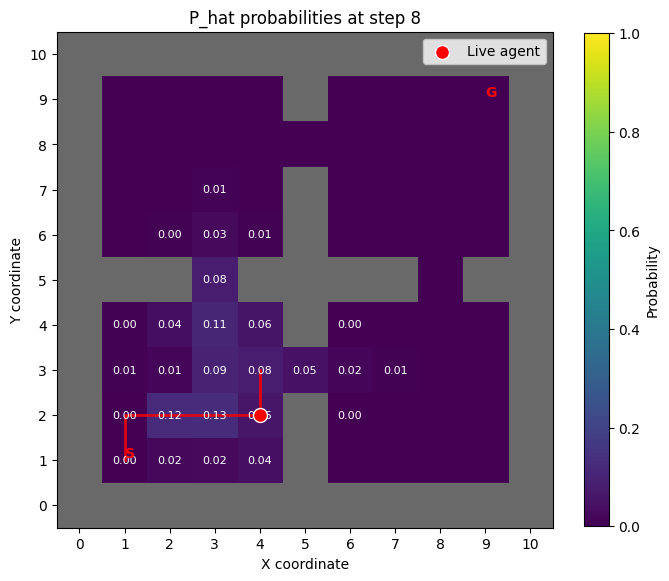

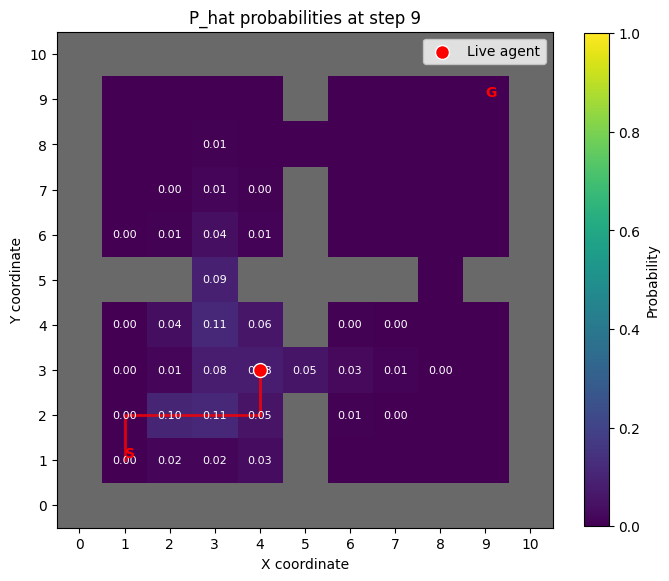

In [27]:
if run_trajectories_single:
  for s in visualised_steps:
    show_distribution(env, model_distributions,step=s, goal_state=goal_state, live_trajectory=live_trajectory)

### Internal model compared to live agent trajectories

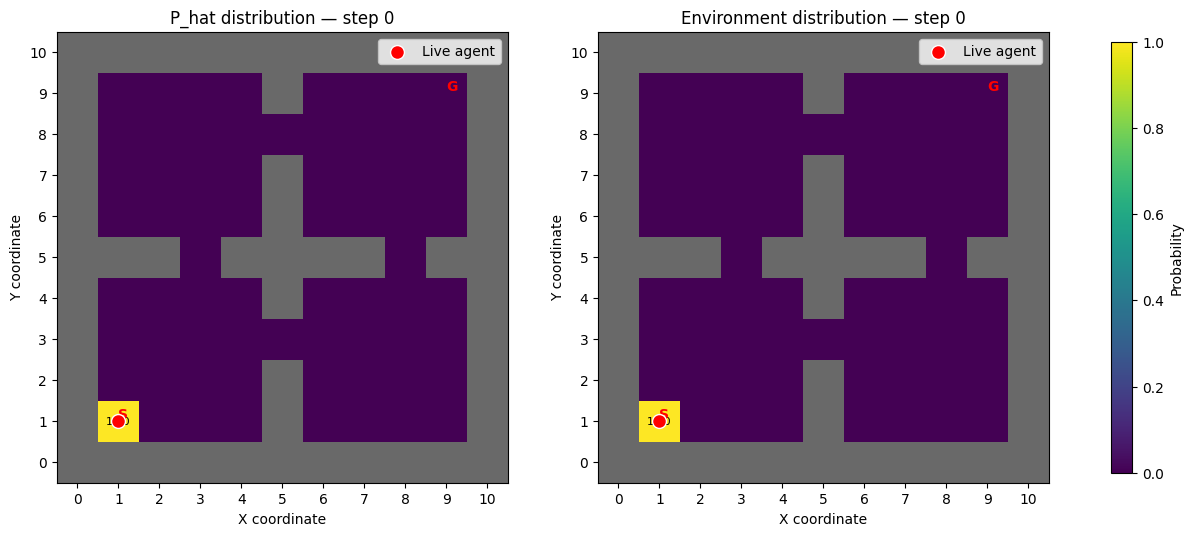

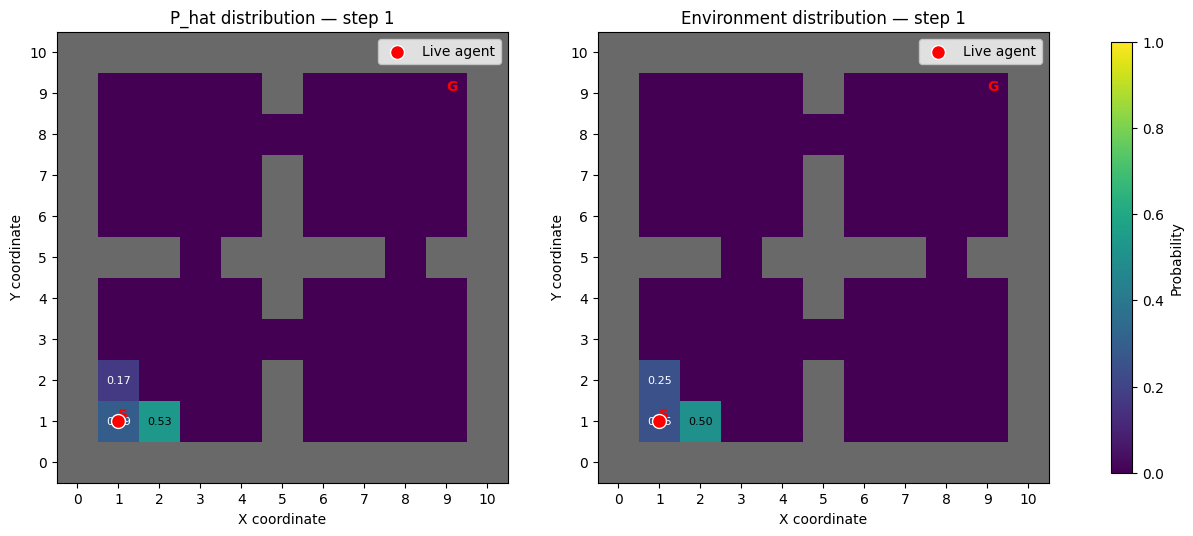

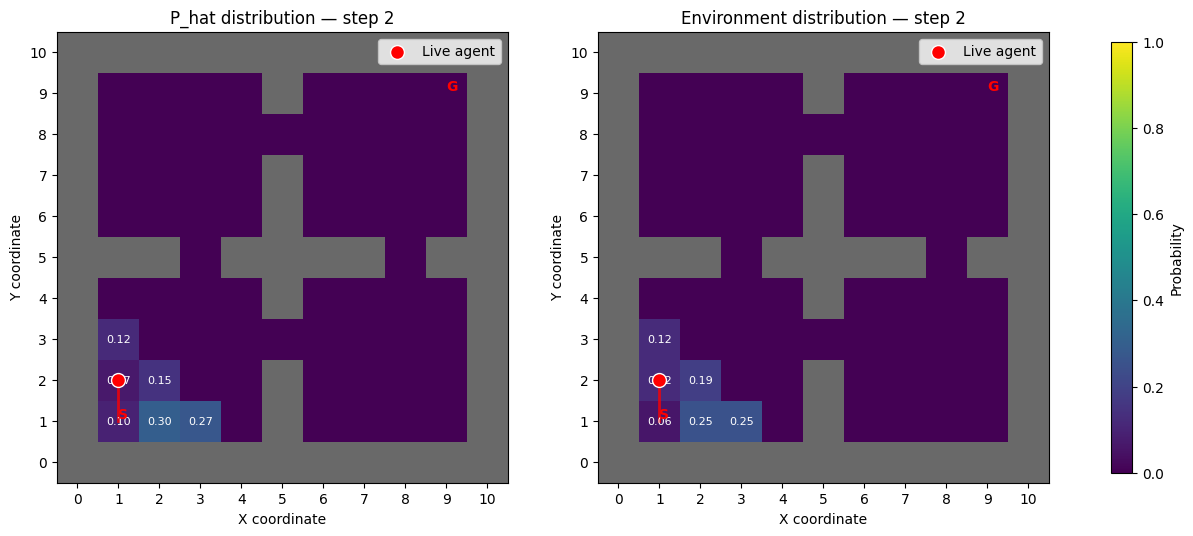

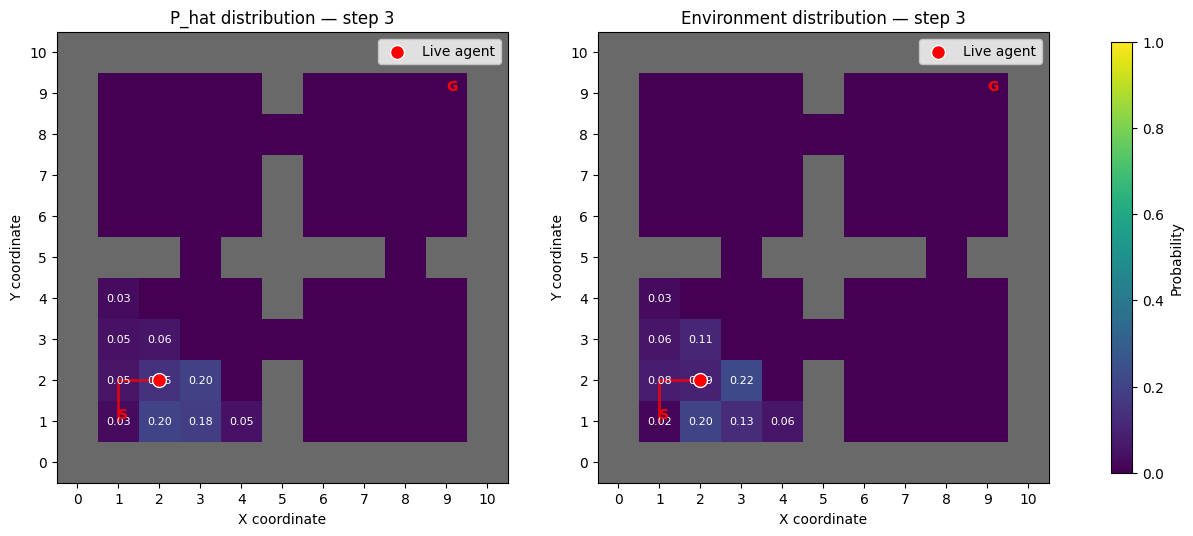

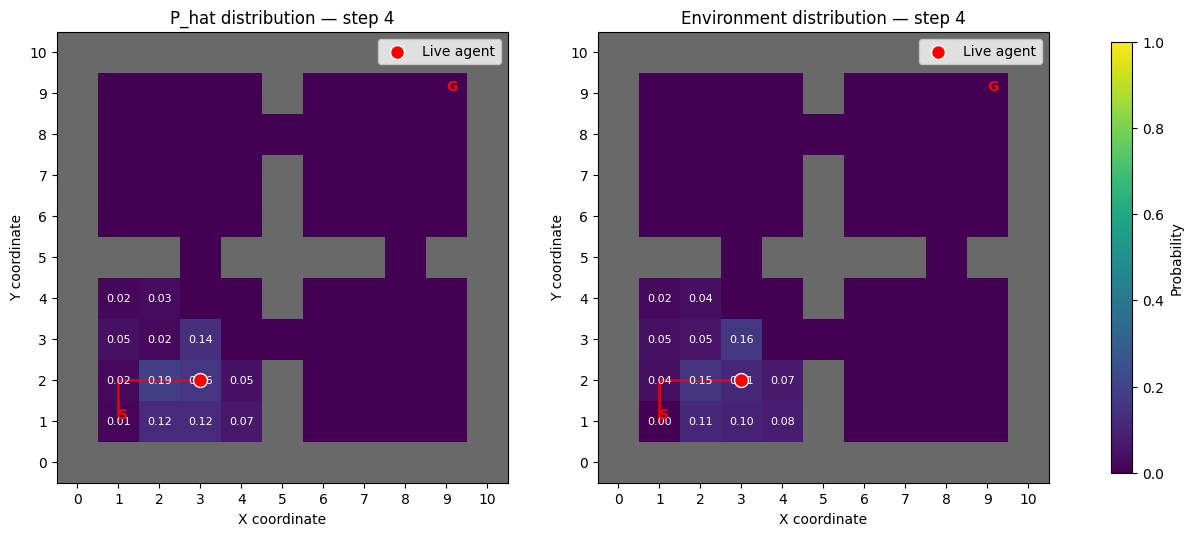

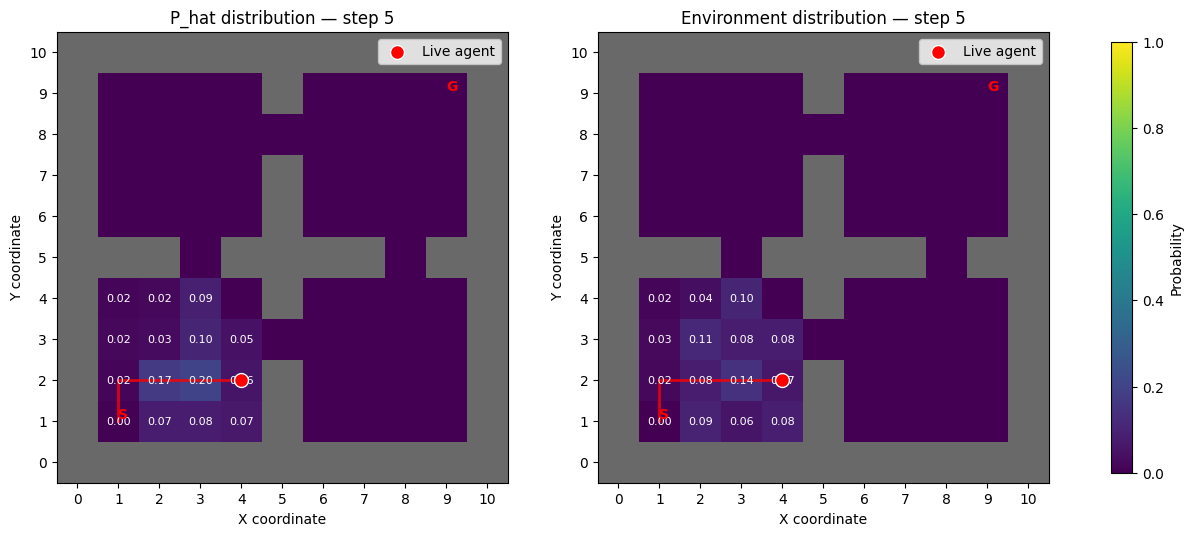

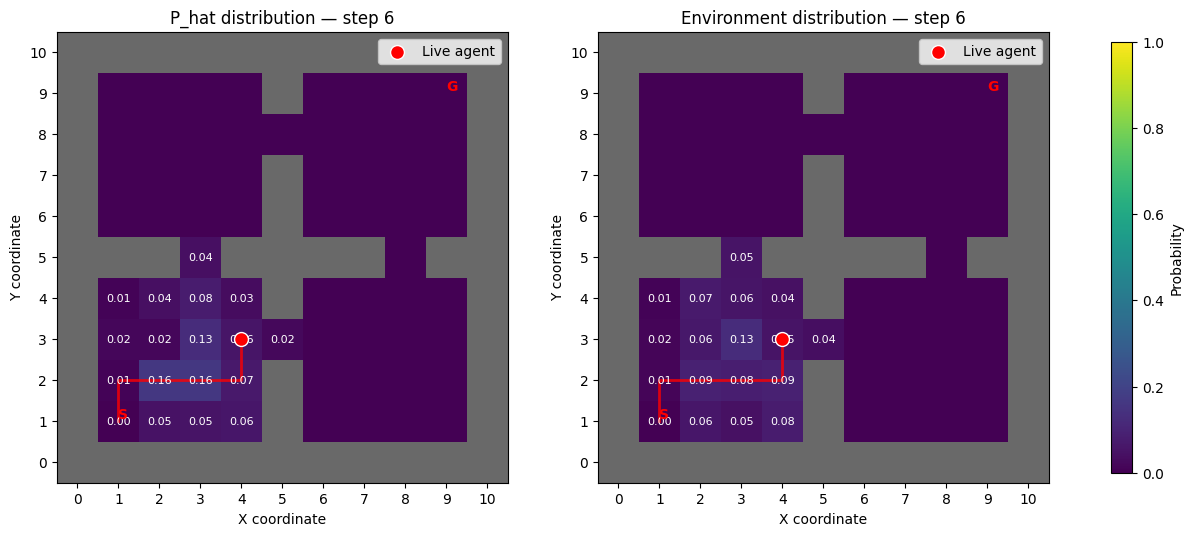

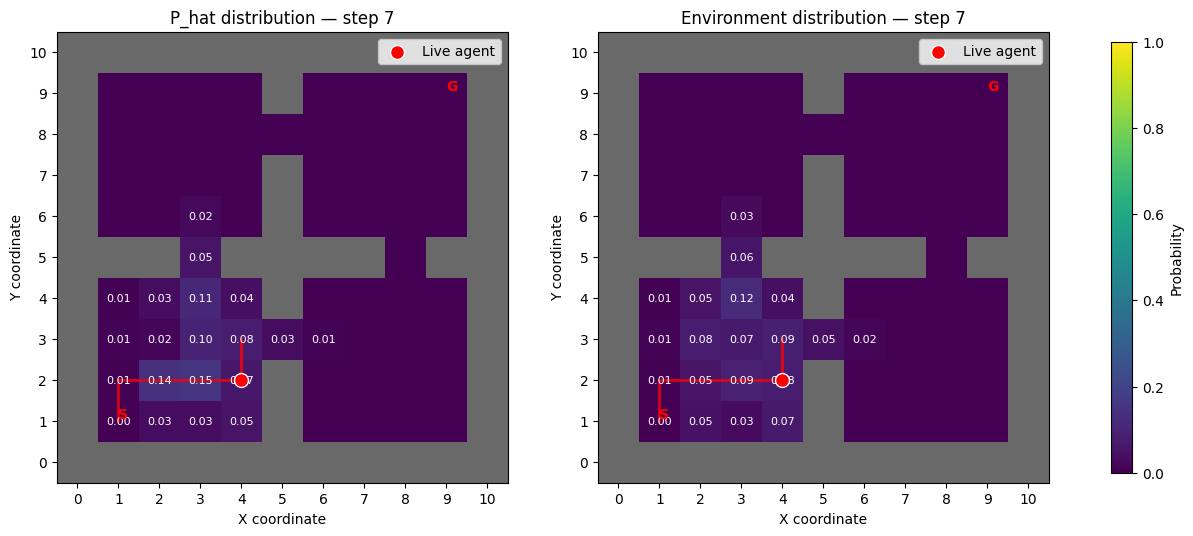

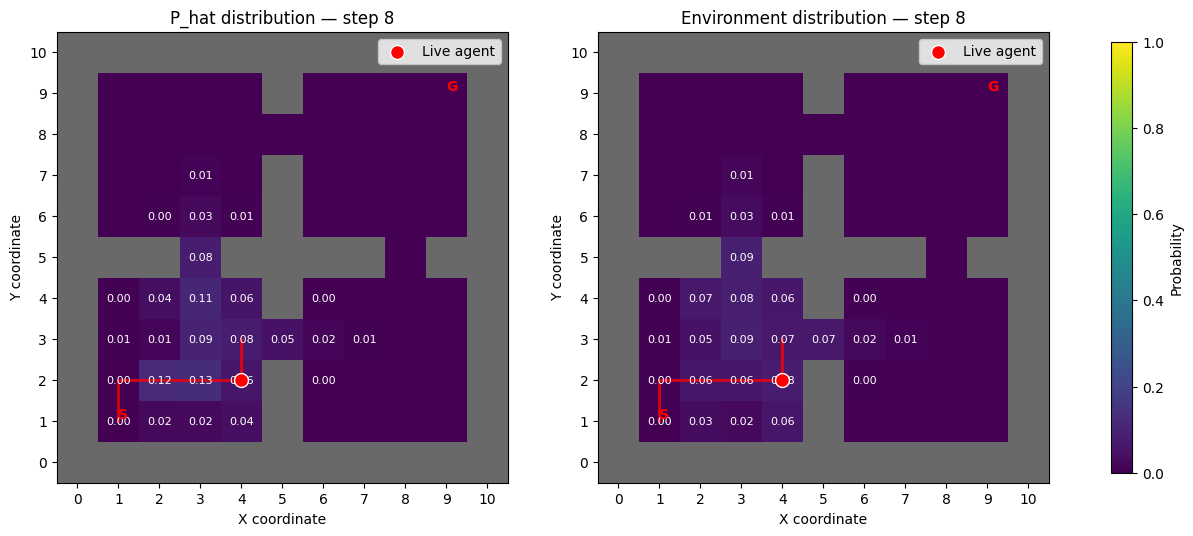

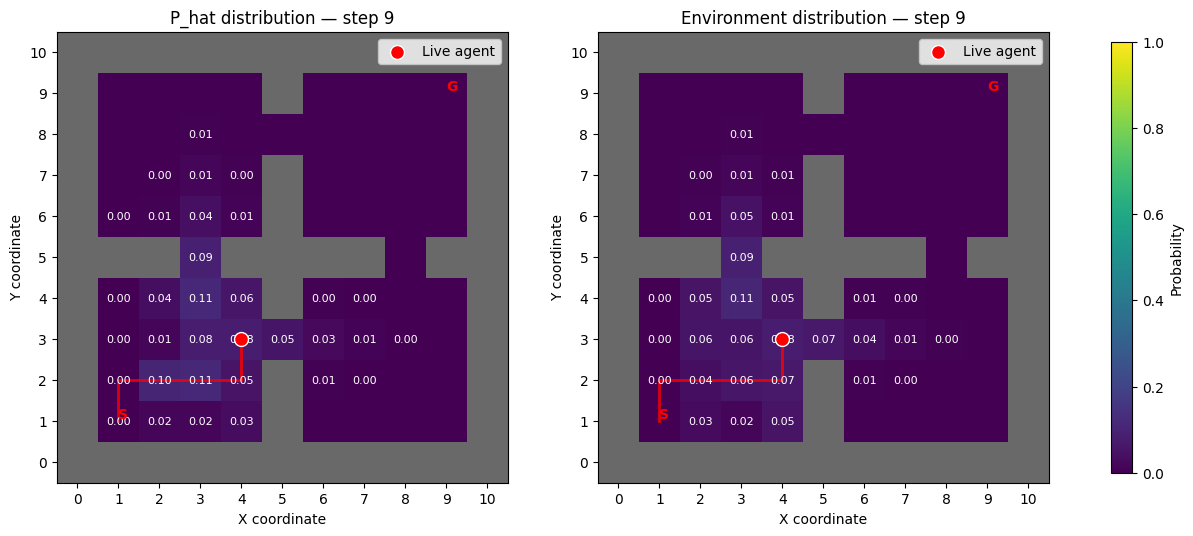

In [28]:
if run_trajectories_single:
  for s in visualised_steps:
    show_distribution_comparison(
      env,
      model_distributions,
      environment_distributions,
      step=s,
      goal_state=goal_state,
      live_trajectory=live_trajectory
    )

## Mathematical comparison

In [10]:
if run_mathematical_multi:
  TRAINING_SEEDS = [8, 18, 28, 38, 48]
  seeded_models = get_seeded_inverted_models(env, goals=goals, training_seeds=TRAINING_SEEDS, n_episodes=100000)

Training seed 8 with 5 goals
Training seed 18 with 5 goals
Training seed 28 with 5 goals
Training seed 38 with 5 goals
Training seed 48 with 5 goals


In [12]:
if run_mathematical_multi:
  goal_index = 3
  goal_state = goals[goal_index]
  n_steps = 50

  seeded_metric_df, seeded_summary_df, distributions_by_seed, P_true = evaluate_seeded_models_exact(env, seeded_models, goals=goals, goal_index=goal_index, n_steps=n_steps)

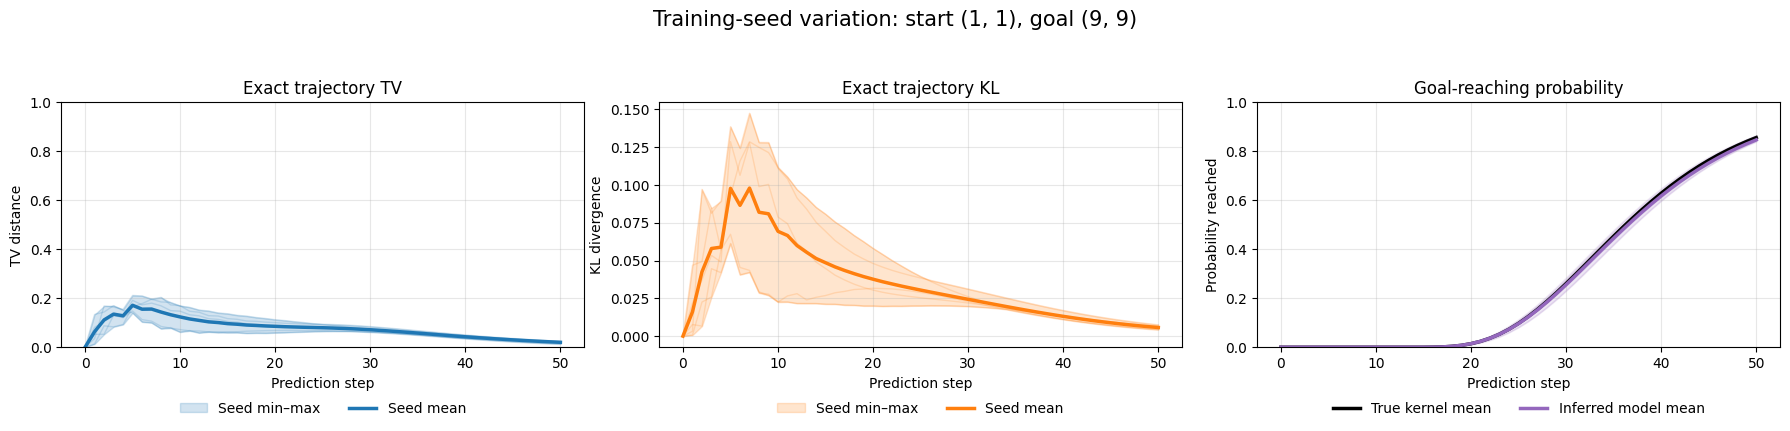

In [13]:
if run_mathematical_multi:
  plot_seeded_phase1_metrics(seeded_metric_df, goal_state=goal_state, start_state=env.start_state)

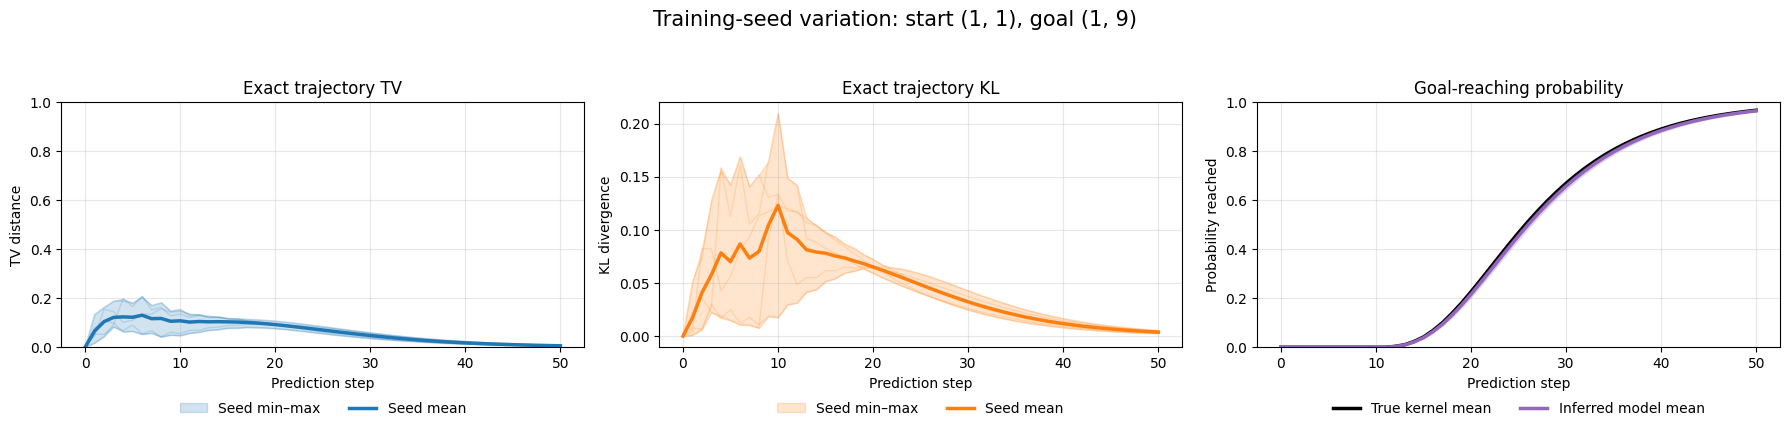

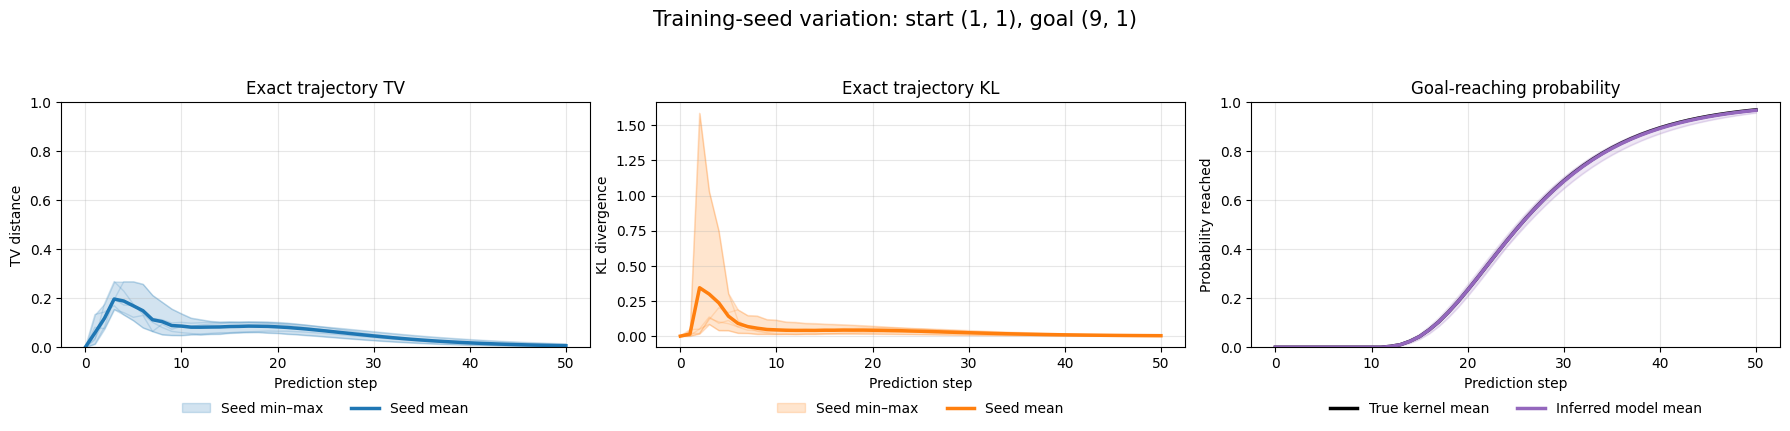

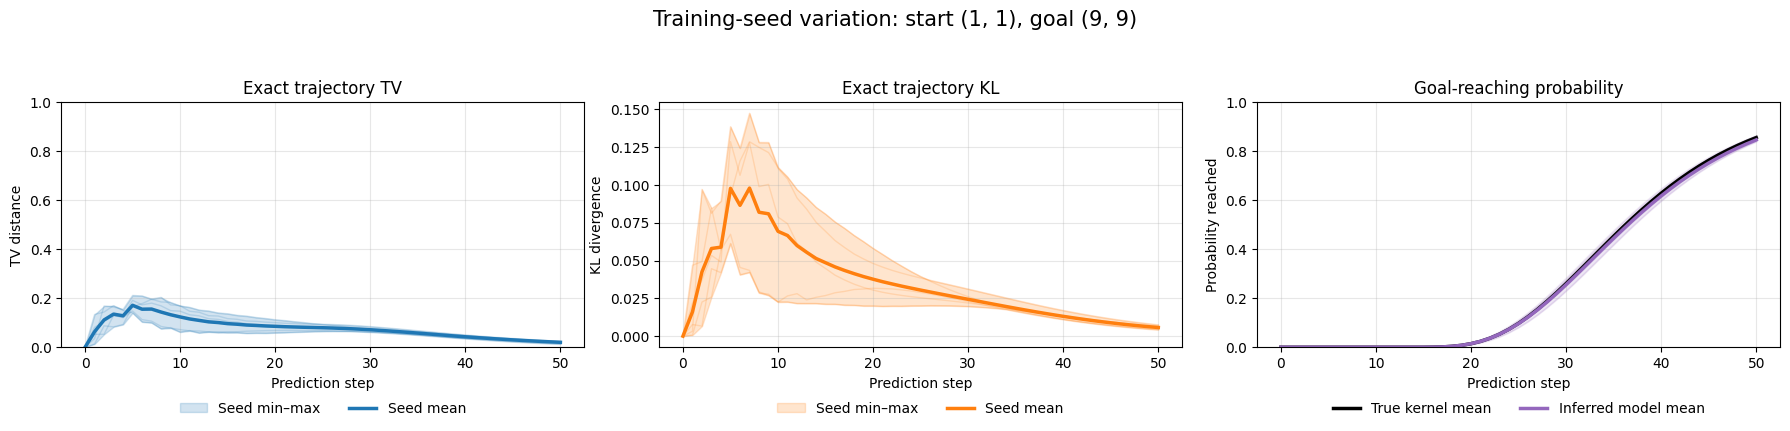

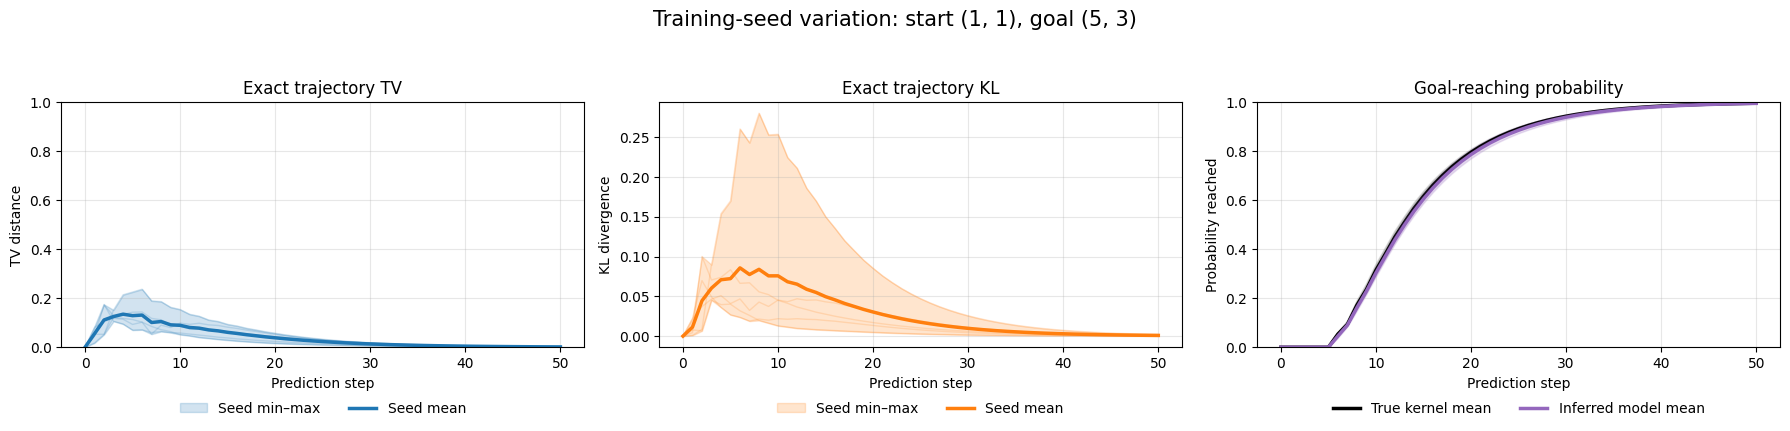

In [14]:
for goal_index in range(len(goals)):
  goal_state = goals[goal_index]
  if goal_state == env.start_state:
    continue
  n_steps = 50

  seeded_metric_df, seeded_summary_df, distributions_by_seed, P_true = evaluate_seeded_models_exact(env, seeded_models, goals=goals, goal_index=goal_index, n_steps=n_steps)
  plot_seeded_phase1_metrics(seeded_metric_df, goal_state=goal_state, start_state=env.start_state)

In [15]:
if run_mathematical_multi:
  print("Results by training seed")
  display(seeded_summary_df.set_index("training seed").round(4))

  print("Aggregate training-seed results")
  aggregate_columns = [column for column in seeded_summary_df.columns if column not in {"training seed","step of maximum TV"}]
  aggregate_summary_df = (seeded_summary_df[aggregate_columns].agg(["mean", "std", "min", "max"]).T)
  display(aggregate_summary_df.round(4))

Results by training seed


,mean transition-row TV,maximum transition-row TV,mean trajectory TV,maximum trajectory TV,step of maximum TV,final trajectory TV,mean trajectory KL,goal-curve MAE,final goal error,final goal bias
training seed,,,,,,,,,,
8,0.1293,0.6288,0.0425,0.1181,3,0.0014,0.0215,0.0077,0.0003,-0.0003
18,0.1220,0.5450,0.0255,0.1219,3,0.0008,0.0072,0.0036,0.0008,-0.0008
28,0.1235,0.5804,0.0596,0.2368,6,0.0018,0.0769,0.0083,0.0009,-0.0009
38,0.1124,0.5635,0.0285,0.1747,2,0.0011,0.0121,0.0059,0.0009,0.0009
48,0.1110,0.6269,0.0440,0.1724,2,0.0024,0.0208,0.0114,0.0021,-0.0021


Aggregate training-seed results


,mean,std,min,max
mean transition-row TV,0.1196,0.0077,0.1110,0.1293
maximum transition-row TV,0.5889,0.0377,0.5450,0.6288
mean trajectory TV,0.0400,0.0137,0.0255,0.0596
maximum trajectory TV,0.1648,0.0484,0.1181,0.2368
final trajectory TV,0.0015,0.0006,0.0008,0.0024
mean trajectory KL,0.0277,0.0281,0.0072,0.0769
goal-curve MAE,0.0074,0.0029,0.0036,0.0114
final goal error,0.0010,0.0007,0.0003,0.0021
final goal bias,-0.0006,0.0011,-0.0021,0.0009


# Breadth test metrics

In [16]:
#Original function refactored with Gemini support
def evaluate_phase1_task_grid(env, seeded_models, goals, evaluation_starts, n_steps):
    metric_frames = []
    summary_frames = []

    for goal_index, goal_state in enumerate(goals):
        for start_state in evaluation_starts:
            if start_state == goal_state:
                continue

            print(
                f"Evaluating start {start_state}, "
                f"goal {goal_state}"
            )

            metrics, summary, _, _ = (
                evaluate_seeded_models_exact(
                    env,
                    seeded_models,
                    goals=goals,
                    goal_index=goal_index,
                    n_steps=n_steps,
                    start_state=start_state,
                )
            )

            metrics["goal"] = str(goal_state)
            metrics["start"] = str(start_state)
            metrics["goal index"] = goal_index

            summary["goal"] = str(goal_state)
            summary["start"] = str(start_state)
            summary["goal index"] = goal_index

            metric_frames.append(metrics)
            summary_frames.append(summary)

    return (
        pd.concat(metric_frames, ignore_index=True),
        pd.concat(summary_frames, ignore_index=True),
    )

In [17]:
EVALUATION_STARTS = [(2, 2), (2, 8), (8, 2), (8, 8)]

phase1_all_metric_df, phase1_task_seed_summary_df = evaluate_phase1_task_grid(env, seeded_models, goals=goals, evaluation_starts=EVALUATION_STARTS, n_steps=50)

Evaluating start (2, 2), goal (1, 1)
Evaluating start (2, 8), goal (1, 1)
Evaluating start (8, 2), goal (1, 1)
Evaluating start (8, 8), goal (1, 1)
Evaluating start (2, 2), goal (1, 9)
Evaluating start (2, 8), goal (1, 9)
Evaluating start (8, 2), goal (1, 9)
Evaluating start (8, 8), goal (1, 9)
Evaluating start (2, 2), goal (9, 1)
Evaluating start (2, 8), goal (9, 1)
Evaluating start (8, 2), goal (9, 1)
Evaluating start (8, 8), goal (9, 1)
Evaluating start (2, 2), goal (9, 9)
Evaluating start (2, 8), goal (9, 9)
Evaluating start (8, 2), goal (9, 9)
Evaluating start (8, 8), goal (9, 9)
Evaluating start (2, 2), goal (5, 3)
Evaluating start (2, 8), goal (5, 3)
Evaluating start (8, 2), goal (5, 3)
Evaluating start (8, 8), goal (5, 3)


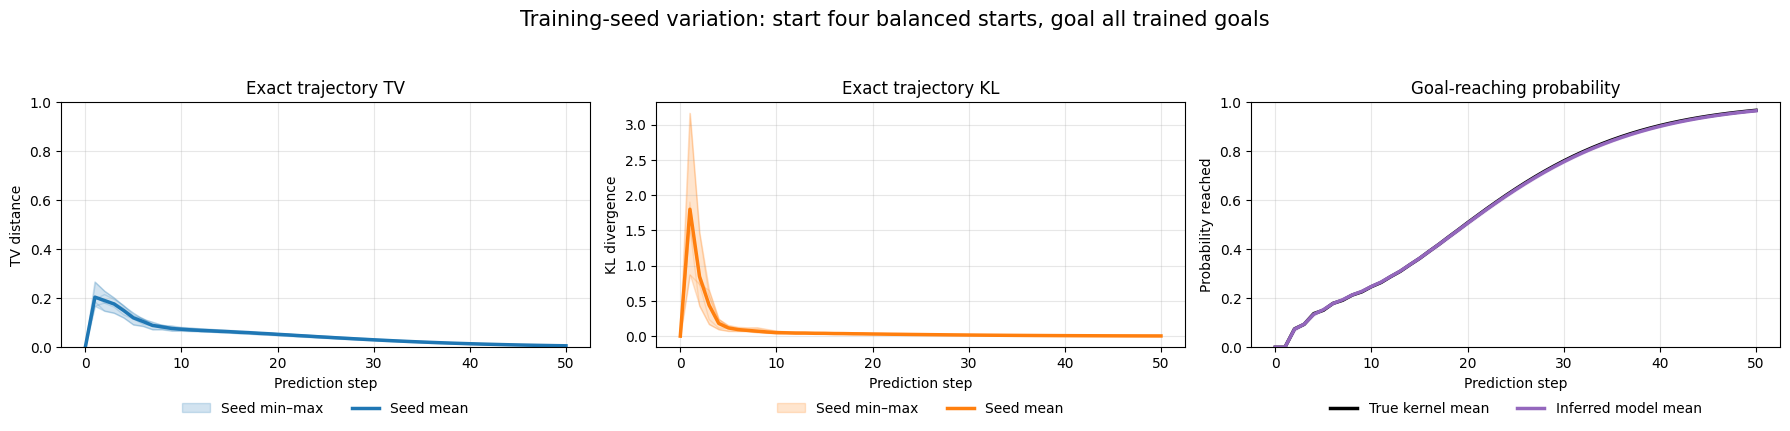

In [18]:
#Gemini supported function for full visualisation, manually verified
curve_columns = [
    "trajectory TV",
    "trajectory KL",
    "true goal probability",
    "inferred goal probability",
    "goal probability error",
    "goal probability bias",
]

phase1_seed_step_df = (
    phase1_all_metric_df
    .groupby(
        ["training seed", "step"],
        as_index=False,
    )[curve_columns]
    .mean()
)

plot_seeded_phase1_metrics(
    phase1_seed_step_df,
    goal_state="all trained goals",
    start_state="four balanced starts",
)

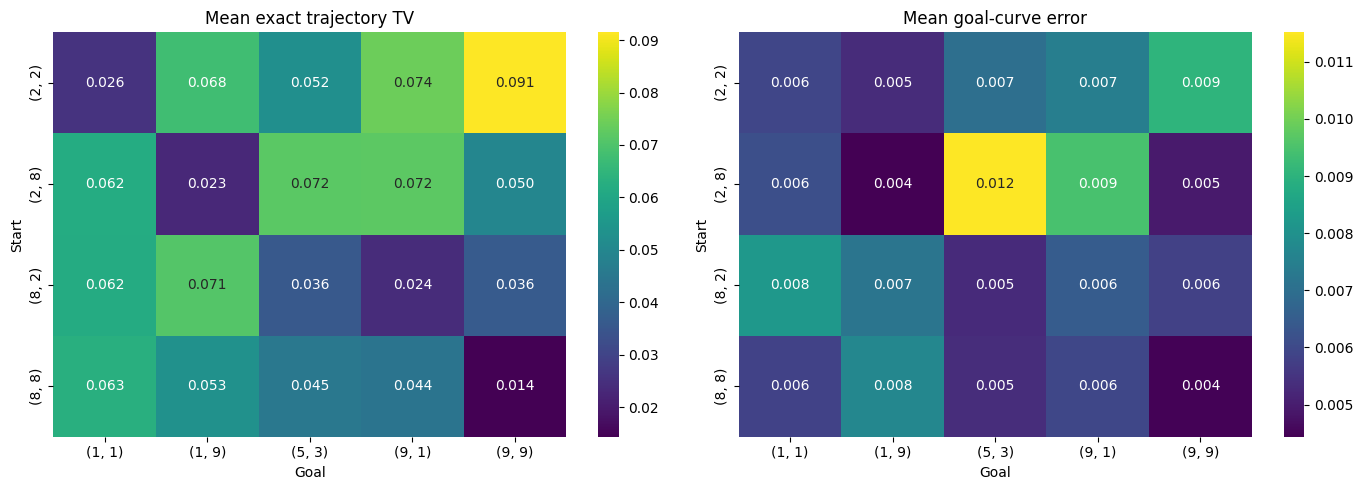

In [19]:
#Gemini supported function for full visualisation, manually verified
import seaborn as sns
import matplotlib.pyplot as plt

task_means_df = (
    phase1_task_seed_summary_df
    .groupby(
        ["start", "goal"],
        as_index=False,
    )[[
        "mean trajectory TV",
        "goal-curve MAE",
    ]]
    .mean()
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

for ax, metric, title in [
    (
        axes[0],
        "mean trajectory TV",
        "Mean exact trajectory TV",
    ),
    (
        axes[1],
        "goal-curve MAE",
        "Mean goal-curve error",
    ),
]:
    matrix = task_means_df.pivot(
        index="start",
        columns="goal",
        values=metric,
    )

    sns.heatmap(
        matrix,
        annot=True,
        fmt=".3f",
        cmap="viridis",
        ax=ax,
    )

    ax.set_title(title)
    ax.set_xlabel("Goal")
    ax.set_ylabel("Start")

plt.tight_layout()
plt.show()

In [20]:
#Aggregate summary formatted with Gemini assistance. Function verified and unchanged
seed_aggregate_df = (
    phase1_task_seed_summary_df
    .groupby("training seed", as_index=False)
    .agg({
        # These are properties of P_hat and are identical
        # across tasks for a given seed.
        "mean transition-row TV": "first",
        "maximum transition-row TV": "first",

        # Average task-level performance.
        "mean trajectory TV": "mean",
        "final trajectory TV": "mean",
        "mean trajectory KL": "mean",
        "goal-curve MAE": "mean",
        "final goal error": "mean",
        "final goal bias": "mean",

        # Preserve the worst task for each seed.
        "maximum trajectory TV": "max",
    })
)

print("Task-aggregated results by training seed")

display(
    seed_aggregate_df
    .set_index("training seed")
    .round(4)
)

phase1_overall_summary_df = (
    seed_aggregate_df
    .drop(columns="training seed")
    .agg(["mean", "std", "min", "max"])
    .T
)

print("Overall Phase 1 results")

display(
    phase1_overall_summary_df.round(4)
)

Task-aggregated results by training seed


,mean transition-row TV,maximum transition-row TV,mean trajectory TV,final trajectory TV,mean trajectory KL,goal-curve MAE,final goal error,final goal bias,maximum trajectory TV
training seed,,,,,,,,,
8,0.1293,0.6288,0.0563,0.0066,0.0862,0.0077,0.0036,-0.0008,0.5400
18,0.1220,0.5450,0.0475,0.0052,0.0629,0.0052,0.0020,-0.0013,0.4462
28,0.1235,0.5804,0.0571,0.0061,0.1406,0.0065,0.0033,-0.0031,0.5600
38,0.1124,0.5635,0.0460,0.0052,0.0653,0.0055,0.0024,-0.0004,0.4927
48,0.1110,0.6269,0.0526,0.0070,0.0928,0.0085,0.0047,-0.0037,0.5080


Overall Phase 1 results


,mean,std,min,max
mean transition-row TV,0.1196,0.0077,0.1110,0.1293
maximum transition-row TV,0.5889,0.0377,0.5450,0.6288
mean trajectory TV,0.0519,0.0050,0.0460,0.0571
final trajectory TV,0.0060,0.0008,0.0052,0.0070
mean trajectory KL,0.0896,0.0313,0.0629,0.1406
goal-curve MAE,0.0067,0.0014,0.0052,0.0085
final goal error,0.0032,0.0010,0.0020,0.0047
final goal bias,-0.0019,0.0014,-0.0037,-0.0004
maximum trajectory TV,0.5094,0.0441,0.4462,0.5600
